# Control de calidad utilizando PaliGemma

https://huggingface.co/google/paligemma-3b-pt-224

# 1. Setup

In [1]:
import torch
if not torch.cuda.is_available():
    print("PaliGemma requiere GPU, y no encuentro tal cosa :-(")

In [2]:
# Algunas cosas que necesitamos antes de empezar
# Recordemos que esto corre en una T4. En CPU no puede cargar el modelo cuantizado
# --> entonces explota
!pip install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.0 MB/s eta 0:00:00


In [3]:
from transformers import AutoProcessor, PaliGemmaForConditionalGeneration
from PIL import Image
import requests

import os
import matplotlib.pyplot as plt

# Para recuperar las imagenes del google drive
from google.colab import userdata
import random
from glob import glob

from google.colab import drive
import shutil


In [4]:
drive.mount('/content/drive')

# Esto es válido solo para mí, porque los datos los tengo almacenados en este directorio de Google Drive
carpeta_trabajo = '/content/drive/MyDrive/Vision Grado/TP Coloquios/Inspección de etiquetas'

# Copio los datos de entrenamiento a la carpeta local para que vuele!
shutil.copytree(carpeta_trabajo+'/dataset', '/content/dataset')


Mounted at /content/drive


'/content/dataset'

# 2. Cargar el modelo

In [9]:
# Voy a usar PaliGemma 3b entrenada para un mix de tareas
# Si no usara mix tendría que hacer fine-tuning
model_id = "google/paligemma-3b-mix-224"
os.environ["HF_TOKEN"] = userdata.get('HUGGINFACE_TOKEN')

# Carga el modelo y el procesador. La primera vez lo descarga desde Hugginface
# Eso automáticamente carga en GPU
model = PaliGemmaForConditionalGeneration.from_pretrained(model_id).eval()
processor = AutoProcessor.from_pretrained(model_id, use_auth_token=os.environ["HF_TOKEN"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/603 [00:00<?, ?it/s]

PaliGemmaForConditionalGeneration(
  (model): PaliGemmaModel(
    (vision_tower): SiglipVisionModel(
      (embeddings): SiglipVisionEmbeddings(
        (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
        (position_embedding): Embedding(256, 1152)
      )
      (encoder): SiglipEncoder(
        (layers): ModuleList(
          (0-26): 27 x SiglipEncoderLayer(
            (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
            (self_attn): SiglipAttention(
              (k_proj): Linear(in_features=1152, out_features=1152, bias=True)
              (v_proj): Linear(in_features=1152, out_features=1152, bias=True)
              (q_proj): Linear(in_features=1152, out_features=1152, bias=True)
              (out_proj): Linear(in_features=1152, out_features=1152, bias=True)
            )
            (layer_norm2): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
            (mlp): SiglipMLP(
              (activation_

# 3. Inferencias

(375, 500)


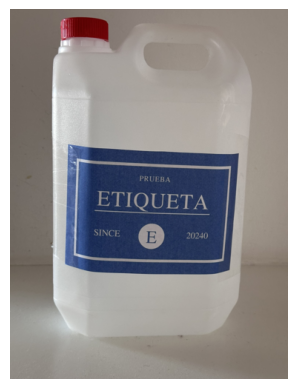

a white jug with a blue label that says etiqueta.


In [11]:
# Le pido al modelo que describa la escena de la imagen en español
image = Image.open('/content/dataset/productoOk/IMG_3871.JPEG')
# Redimensionar la imagen (mantiene la relación de aspecto)
image.thumbnail((500,500))
print(image.size)

plt.imshow(image)
plt.axis('off')
plt.show()

prompt = "<image> Describe the image in detail."
model_inputs = processor(text=prompt, images=image, return_tensors="pt")
input_len = model_inputs["input_ids"].shape[-1]

# Tengo el modelo en GPU => me aseguro de cargar los inputs también en GPU
model_inputs = {k: v.to(device) for k, v in model_inputs.items()}

with torch.inference_mode():
    generation = model.generate(**model_inputs, max_new_tokens=100, do_sample=False)
    generation = generation[0][input_len:]
    decoded = processor.decode(generation, skip_special_tokens=True)
    print(decoded)

  0%|          | 0/15 [00:00<?, ?it/s]

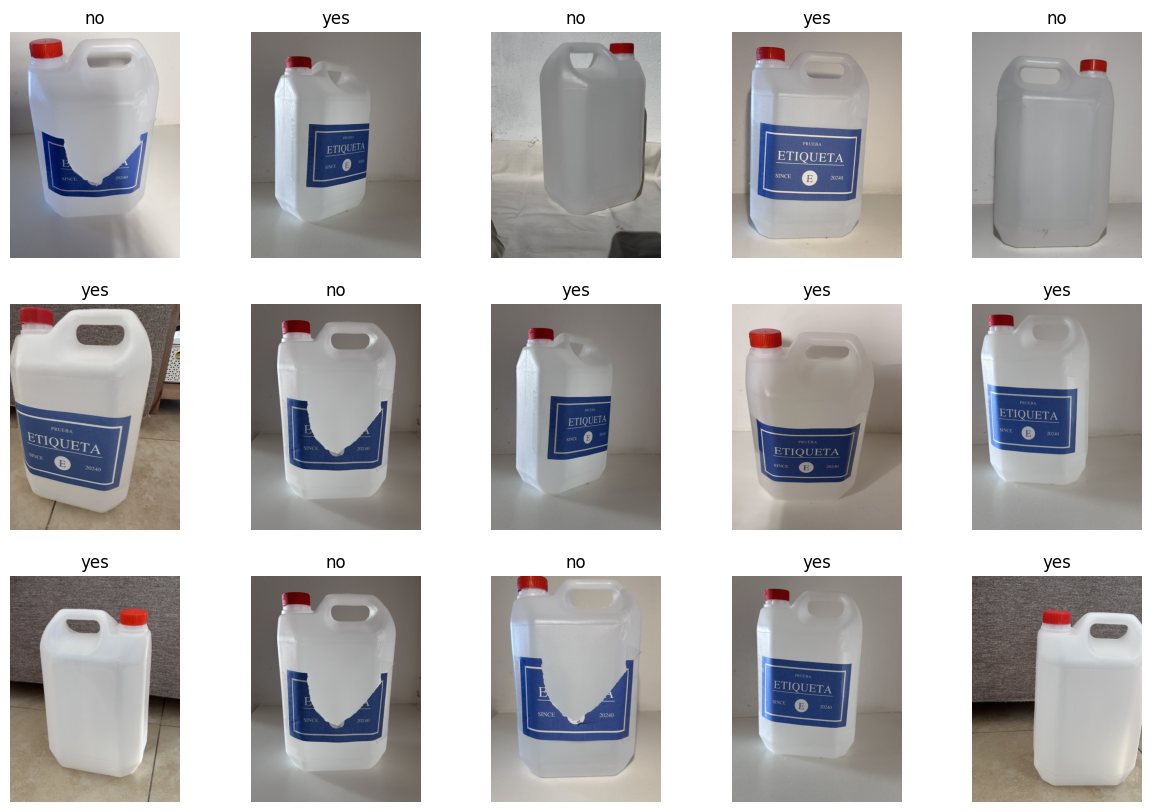

In [13]:
# Para mostrar barras de progreso
from tqdm.notebook import tqdm

# Le pido que verifique el envase. ACA ESTÁ LA PROGRAMACIÓN DEL TP
prompt = "<image> is the product label properly attached and intact? Does the product have a good appearance on its packaging?"

prompt = "<image> is the blue product label attached and intact?"
# Fin de la programación del TP

# Voy a procesar el batch de imagenes buenas y malas
image_paths = glob('dataset/**/*.*', recursive=True)

# Seleccionar imágenes aleatorias
N_image_rows = 3
N_image_cols = 5
random_images = random.sample(image_paths, N_image_rows*N_image_cols)

# Configurar el tamaño de la figura
plt.figure(figsize=(15, 10))

for i in tqdm(range(N_image_rows*N_image_cols)):
  plt.subplot(N_image_rows, N_image_cols, i + 1)
  image = Image.open(random_images[i])
  plt.imshow(image)
  plt.axis('off')

  model_inputs = processor(text=prompt, images=image, return_tensors="pt")
  input_len = model_inputs["input_ids"].shape[-1]

  # Tengo el modelo en GPU => me aseguro de cargar los inputs también en GPU
  model_inputs = {k: v.to(device) for k, v in model_inputs.items()}

  # Imprimir las rutas seleccionadas
  with torch.inference_mode():
      generation = model.generate(**model_inputs, max_new_tokens=100, do_sample=False)
      generation = generation[0][input_len:]
      decoded = processor.decode(generation, skip_special_tokens=True)
      plt.title(decoded)
      #print(decoded)
